In [2]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW # Updated to use PyTorch's native AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
import random
import os

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
def set_seed(seed_val=42):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)

set_seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")


Using device: cpu


In [3]:
train_path = "/home/baadalvm/Downloads/train_split.csv"
val_path   = "/home/baadalvm/Downloads/validation_split.csv"
test_path  = "/home/baadalvm/Downloads/test_split.csv"
text_column = "text"
label_column = "label"

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

print("Loaded dataset sizes:")
print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")



Loaded dataset sizes:
Train: 70000
Val:   15000
Test:  15000


In [4]:
# @title Preprocess Data
def preprocess_data(df, text_column, label_column):
    # Clean the data
    df = df.dropna(subset=[text_column, label_column])

    # Ensure labels are numeric
    if df[label_column].dtype == 'object':
        unique_labels = df[label_column].unique()
        label_map = {label: idx for idx, label in enumerate(unique_labels)}
        df['label_encoded'] = df[label_column].map(label_map)
        print(f"Label mapping created: {label_map}")
    else:
        df['label_encoded'] = df[label_column]
        # Create a dummy map if labels are already numeric
        unique_labels = sorted(df[label_column].unique())
        label_map = {val: val for val in unique_labels}

    print(f"\nClass distribution:\n{df[label_column].value_counts()}")
    return df, label_map
combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

df_processed, label_map = preprocess_data(combined_df, text_column, label_column)
print("\nLabel map:", label_map)
combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

df_processed, label_map = preprocess_data(combined_df, text_column, label_column)
print("\nLabel map:", label_map)



Class distribution:
label
0    56716
1    43284
Name: count, dtype: int64

Label map: {0: 0, 1: 1}

Class distribution:
label
0    56716
1    43284
Name: count, dtype: int64

Label map: {0: 0, 1: 1}


In [5]:
label_counts = df_processed["label_encoded"].value_counts()
single_sample = label_counts[label_counts == 1].index

df_processed = df_processed[~df_processed["label_encoded"].isin(single_sample)]
print(f"\nRemoved {len(single_sample)} single-sample classes.")
train_size = len(train_df)
val_size = len(val_df)

train_processed = df_processed.iloc[:train_size]
val_processed   = df_processed.iloc[train_size : train_size + val_size]
test_processed  = df_processed.iloc[train_size + val_size :]

print("\nProcessed dataset sizes:")
print(f"Train: {len(train_processed)}")
print(f"Val:   {len(val_processed)}")
print(f"Test:  {len(test_processed)}")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')



Removed 0 single-sample classes.

Processed dataset sizes:
Train: 70000
Val:   15000
Test:  15000


In [6]:
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = int(self.labels.iloc[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }
train_dataset = TextClassificationDataset(
    train_processed[text_column], train_processed["label_encoded"], tokenizer
)
val_dataset = TextClassificationDataset(
    val_processed[text_column], val_processed["label_encoded"], tokenizer
)
test_dataset = TextClassificationDataset(
    test_processed[text_column], test_processed["label_encoded"], tokenizer
)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("\nDataloaders created successfully.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(label_map)

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_classes
).to(device)

print("Model loaded.")




Dataloaders created successfully.


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded.


In [7]:
def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0

    for batch in tqdm(data_loader, desc="Training"):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    return total_loss / len(data_loader)


def evaluate_model(model, data_loader, device):
    model.eval()
    predictions = []
    true_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()
            _, preds = torch.max(outputs.logits, dim=1)

            predictions.extend(preds.cpu().tolist())
            true_labels.extend(labels.cpu().tolist())

    accuracy = accuracy_score(true_labels, predictions)
    return accuracy, total_loss / len(data_loader)


In [8]:
epochs = 3
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

best_accuracy = 0
best_model_state = None

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("-"*40)

    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_acc, val_loss = evaluate_model(model, val_loader, device)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val Acc:    {val_acc:.4f}")

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_model_state = model.state_dict().copy()
        print("New best model!")

if best_model_state:
    model.load_state_dict(best_model_state)
    print("\nBest model restored.")



Epoch 1/3
----------------------------------------


Training:   0%|          | 0/4375 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/938 [00:00<?, ?it/s]

Train Loss: 0.1066
Val Loss:   0.0784
Val Acc:    0.9806
New best model!

Epoch 2/3
----------------------------------------


Training:   0%|          | 0/4375 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/938 [00:00<?, ?it/s]

Train Loss: 0.0364
Val Loss:   0.0704
Val Acc:    0.9843
New best model!

Epoch 3/3
----------------------------------------


Training:   0%|          | 0/4375 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/938 [00:00<?, ?it/s]

Train Loss: 0.0131
Val Loss:   0.0824
Val Acc:    0.9853
New best model!

Best model restored.


In [16]:
print(f"Train Loss: {train_loss:.4f}")
print(f"Val Loss:   {val_loss:.4f}")
print(f"Val Acc:    {val_acc:.4f}")


Train Loss: 0.0131
Val Loss:   0.0824
Val Acc:    0.9853


In [18]:
print("\nTraining Summary")
for i in range(epochs):
    print(
        f"Epoch {i+1}: "
        f"Train Loss = {train_loss[i]:.4f}, "
        f"Val Loss = {val_loss[i]:.4f}, "
        f"Val Accuracy = {val_acc[i]:.4f}"
    )




Training Summary


TypeError: 'float' object is not subscriptable

In [23]:
# Load best model weights
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("\nTraining complete. Best model loaded.")

    # Save best model to disk
    torch.save({
        'model_state_dict': best_model_state,
        'best_accuracy': best_accuracy,
        'epochs': epochs,
        'train_losses':train_loss,
        'Validation_losses':val_loss,
        'Validation_accuracy':val_acc,
    }, 'best_model.pth')

    print("Best model saved to 'best_model.pth'")



In [21]:
import os

# Get current working directory
cwd = os.getcwd()
print("Current working directory:", cwd)

# Check if the model exists there
if "best_model.pth" in os.listdir(cwd):
    print("Best model is saved here:", os.path.join(cwd, "best_model.pth"))
else:
    print("best_model.pth not found in current directory.")


Current working directory: /home/baadalvm/Downloads
Best model is saved here: /home/baadalvm/Downloads/best_model.pth


Starting training...

Epoch 1/3
--------------------------------------------------


Evaluating: 100%|██████████| 938/938 [06:18<00:00,  2.48it/s]


Train Loss: 0.0244, Val Loss: 0.0871, Val Accuracy: 0.9856
New best model found! (Accuracy: 0.9856)

Epoch 2/3
--------------------------------------------------


Evaluating: 100%|██████████| 938/938 [06:14<00:00,  2.51it/s]


Train Loss: 0.0084, Val Loss: 0.1133, Val Accuracy: 0.9847

Epoch 3/3
--------------------------------------------------


Evaluating: 100%|██████████| 938/938 [07:54<00:00,  1.98it/s]


Train Loss: 0.0025, Val Loss: 0.1146, Val Accuracy: 0.9859
New best model found! (Accuracy: 0.9859)

Training complete. Best model loaded.
Best model saved to 'best_model.pth'


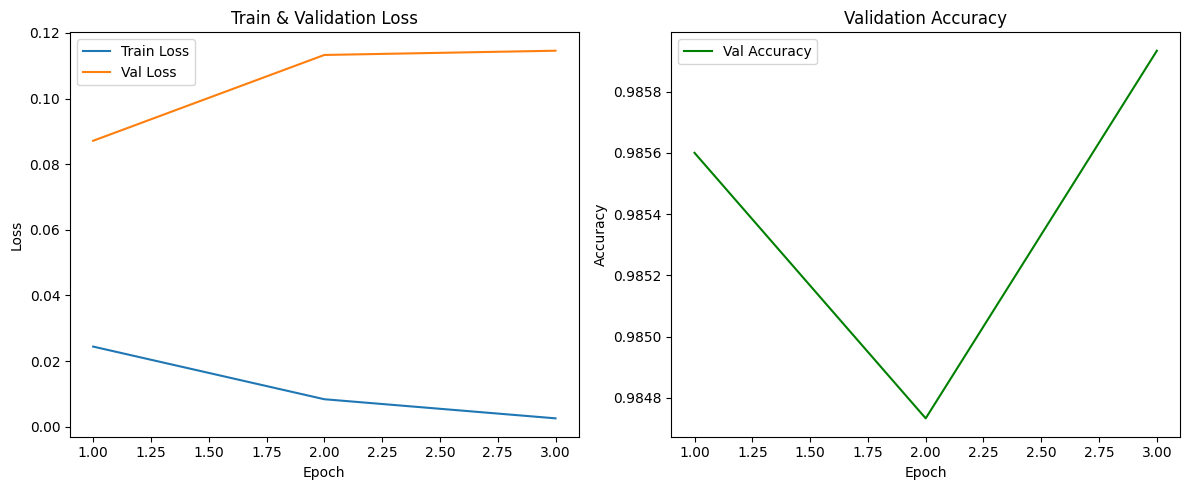

Evaluating: 100%|██████████| 938/938 [08:45<00:00,  1.78it/s]  



Test Accuracy: 0.9863


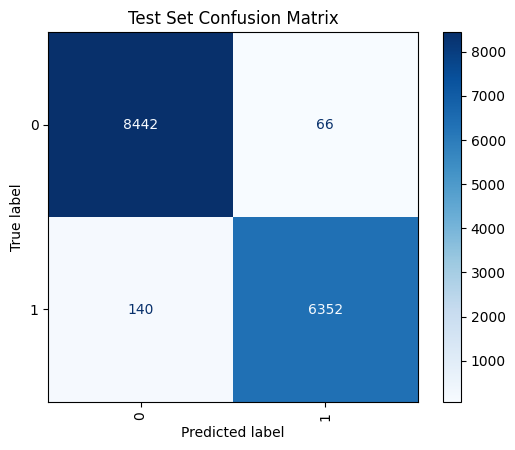

In [24]:
import torch
from torch.utils.data import DataLoader
from transformers import DistilBertForSequenceClassification, AdamW, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import matplotlib.pyplot as plt
epochs = 3
learning_rate = 2e-5
weight_decay = 0.01

optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

train_losses = []
val_losses = []
val_accuracies = []

best_accuracy = 0
best_model_state = None

def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in tqdm(data_loader, desc="Training"):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
    return total_loss / len(data_loader)


def evaluate_model(model, data_loader, device):
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)

            total_loss += outputs.loss.item()
            _, preds = torch.max(outputs.logits, dim=1)
            predictions.extend(preds.cpu().tolist())
            true_labels.extend(labels.cpu().tolist())

    accuracy = accuracy_score(true_labels, predictions)
    return accuracy, total_loss / len(data_loader), predictions, true_labels

print("Starting training...")

for epoch in range(epochs):
    print(f'\nEpoch {epoch + 1}/{epochs}')
    print('-'*50)

    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_acc, val_loss, _, _ = evaluate_model(model, val_loader, device)

    # Track metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}')

    # Save best model
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_model_state = model.state_dict().copy()
        print(f'New best model found! (Accuracy: {best_accuracy:.4f})')

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("\nTraining complete. Best model loaded.")

    torch.save({
        'model_state_dict': best_model_state,
        'best_accuracy': best_accuracy,
        'epochs': epochs,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies
    }, 'best_model.pth')

    print("Best model saved to 'best_model.pth'")

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train & Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), val_accuracies, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

test_acc, _, test_preds, test_labels = evaluate_model(model, test_loader, device)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_map.keys())
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Test Set Confusion Matrix")
plt.show()


Starting training...

Epoch 1/5
--------------------------------------------------


Evaluating: 100%|██████████| 938/938 [06:11<00:00,  2.52it/s]


Train Loss: 0.0137, Val Loss: 0.1054, Val Accuracy: 0.9855
New best model found! (Accuracy: 0.9855)

Epoch 2/5
--------------------------------------------------


Evaluating: 100%|██████████| 938/938 [06:21<00:00,  2.46it/s]


Train Loss: 0.0070, Val Loss: 0.1117, Val Accuracy: 0.9862
New best model found! (Accuracy: 0.9862)

Epoch 3/5
--------------------------------------------------


...

Train Loss: 0.0040, Val Loss: 0.1097, Val Accuracy: 0.9868
New best model found! (Accuracy: 0.9868)

Epoch 4/5
--------------------------------------------------


Evaluating: 100%|██████████| 938/938 [05:53<00:00,  2.65it/s]


Train Loss: 0.0016, Val Loss: 0.1341, Val Accuracy: 0.9861

Epoch 5/5
--------------------------------------------------


Evaluating: 100%|██████████| 938/938 [05:55<00:00,  2.64it/s]


Train Loss: 0.0010, Val Loss: 0.1325, Val Accuracy: 0.9865

Training complete. Best model loaded.
Best model saved to 'best_model_update.pth'


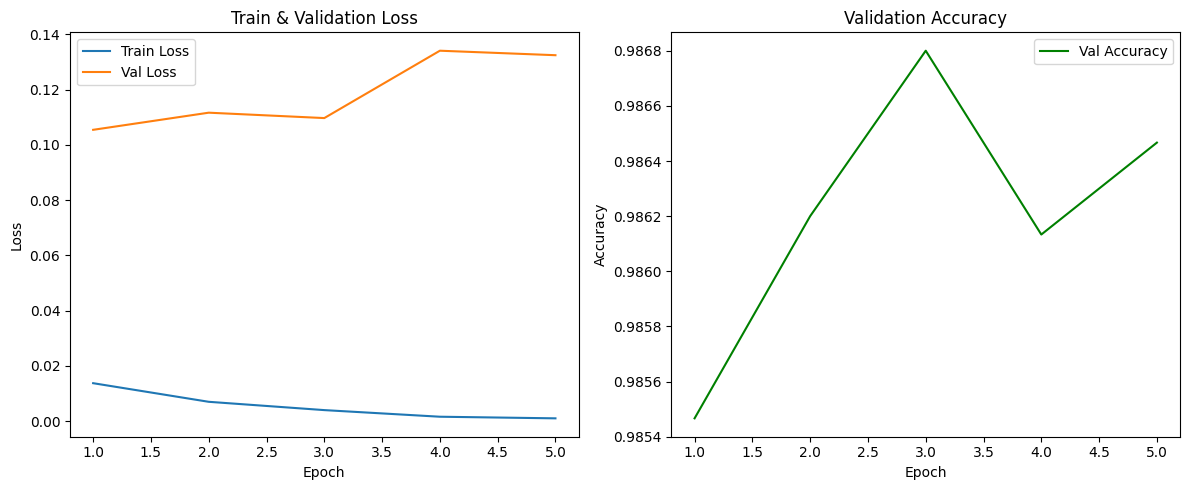

Evaluating: 100%|██████████| 938/938 [07:15<00:00,  2.15it/s]  


Test Accuracy: 0.9864


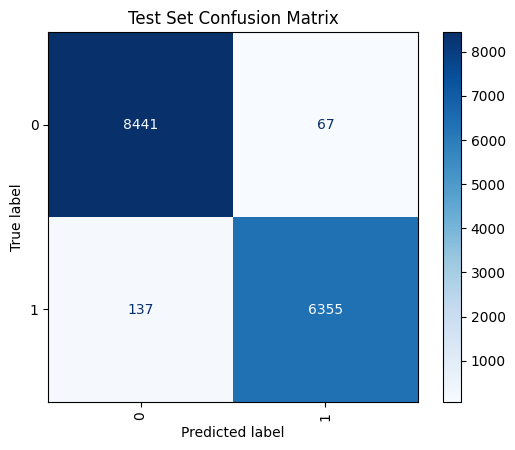

In [25]:
import torch
from torch.utils.data import DataLoader
from transformers import DistilBertForSequenceClassification, AdamW, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import matplotlib.pyplot as plt
epochs = 5
learning_rate = 2e-5
weight_decay = 0.01

optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

train_losses = []
val_losses = []
val_accuracies = []

best_accuracy = 0
best_model_state = None

def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in tqdm(data_loader, desc="Training"):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
    return total_loss / len(data_loader)


def evaluate_model(model, data_loader, device):
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)

            total_loss += outputs.loss.item()
            _, preds = torch.max(outputs.logits, dim=1)
            predictions.extend(preds.cpu().tolist())
            true_labels.extend(labels.cpu().tolist())

    accuracy = accuracy_score(true_labels, predictions)
    return accuracy, total_loss / len(data_loader), predictions, true_labels

print("Starting training...")

for epoch in range(epochs):
    print(f'\nEpoch {epoch + 1}/{epochs}')
    print('-'*50)

    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_acc, val_loss, _, _ = evaluate_model(model, val_loader, device)

    # Track metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}')

    # Save best model
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_model_state = model.state_dict().copy()
        print(f'New best model found! (Accuracy: {best_accuracy:.4f})')

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("\nTraining complete. Best model loaded.")

    torch.save({
        'model_state_dict': best_model_state,
        'best_accuracy': best_accuracy,
        'epochs': epochs,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies
    }, 'best_model.pth')

    print("Best model saved to 'best_model_update.pth'")

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train & Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), val_accuracies, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

test_acc, _, test_preds, test_labels = evaluate_model(model, test_loader, device)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_map.keys())
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Test Set Confusion Matrix")
plt.show()


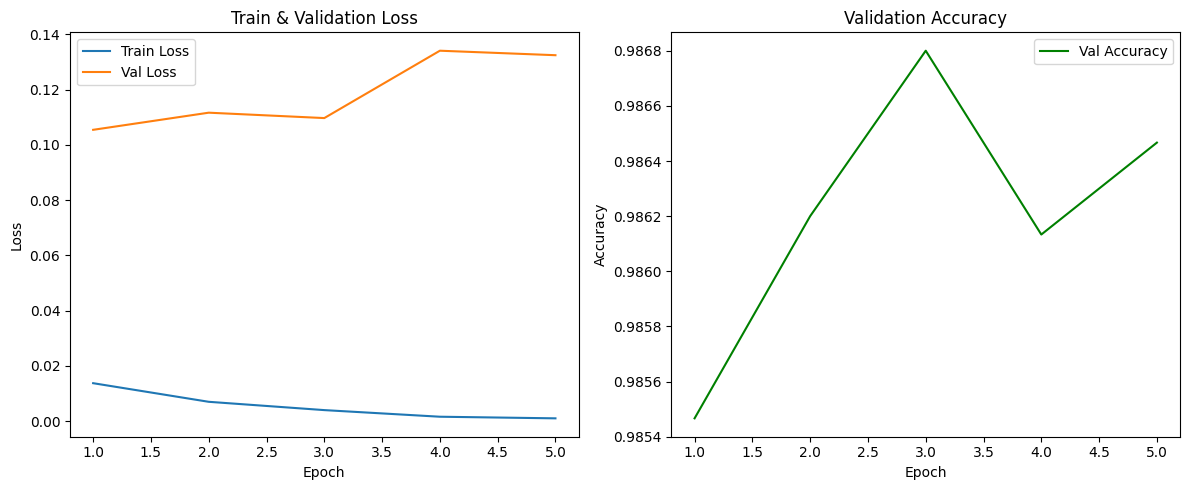

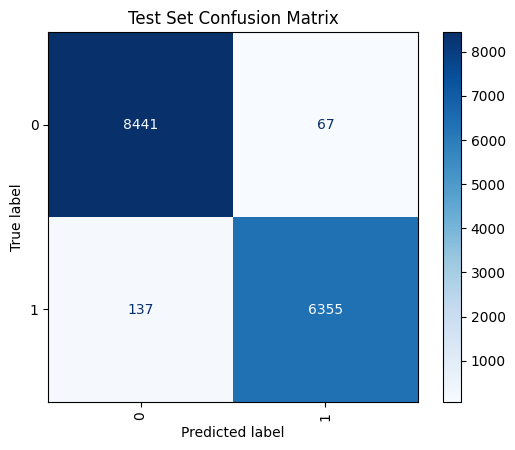

In [33]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train & Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), val_accuracies, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

plt.tight_layout()

#  SAVE PLOT
plt.savefig("training_plots.png", dpi=300)

plt.show()


# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_map.keys())
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Test Set Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [31]:
save_path = os.path.join(os.getcwd(), "best_model_update.pth")

torch.save({
    'model_state_dict': best_model_state,
    'best_accuracy': best_accuracy,
    'epochs': epochs,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'val_accuracies': val_accuracies
}, save_path)

print(f"Best model saved to: {save_path}")


Best model saved to: /home/baadalvm/Downloads/best_model_update.pth


In [29]:
import os

print("Current working directory:", os.getcwd())
print("Files in directory:", os.listdir(os.getcwd()))


Current working directory: /home/baadalvm/Downloads
Files in directory: ['Practical 9.ipynb', 'Practical 6_Combustion Kinetics(1).zip', 'Practical_8.pdf', 'dlr_T1600_phi0.5.png', 'dlr.yaml', 'unet_output_final_MC_DSF=5', 'Filter and Downsampling factor.ipynb', 'final.ipynb', 'kanika.zip', 'Combustion practical.ipynb', 'rxnpath_T1400_phi2.4.png', 'ReactionPathDiagram.dot', 'dlr_T900_phi1.0.dot', '1-s2.0-S0010218019300501-mmc2.zip', 'an.wbpj', 'UNet2D_best1_20251014-210730.pt', 'Practical 10.ipynb', 'Practical 6_CombustionKinetics.ipynb', 'new_1.ipynb', 'Practical 3_Combustion Kinetics.ipynb', 'losses_20251019-153325.csv', 'rxnpath_T1200_phi1.0.dot', 'input_norm_stats.npz', 'excite_therm.txt', 'thero.txt', 'NewCode.ipynb', 'Reduced_50_T1200_phi2.0.png', '1-s2.0-S0010218019300501-mmc2(12).zip', 'unet_output_final_more epoch', 'testing results phi08.pdf', 'new.ipynb', '1-s2.0-S0010218019300501-mmc2(10).zip', 'unet_output_progress_only_model', '1-s2.0-S0010218019300501-mmc2(17).zip', 'examp

In [28]:
import os

# Get current working directory
cwd = os.getcwd()
print("Current working directory:", cwd)

# Check if the model exists there
if "best_model_updated.pth" in os.listdir(cwd):
    print("Best model is saved here:", os.path.join(cwd, "best_model.pth"))
else:
    print("best_model_updated.pth not found in current directory.")


Current working directory: /home/baadalvm/Downloads
best_model_updated.pth not found in current directory.


In [ ]:
import torch
import pandas as pd
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

checkpoint = torch.load("best_model_update.pth", map_location="cpu")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(checkpoint['val_accuracies'])  # or set manually
)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


csv_path = "/home/baadalvm/Downloads/Demonstration dataset.csv"

df = pd.read_csv(csv_path)

print("Loaded Test CSV:")
print(df.head())

# Change column names if needed:
TEXT_COL = "text"
LABEL_COL = "label"

class TestDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.df = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df.iloc[idx][TEXT_COL])
        label = int(self.df.iloc[idx][LABEL_COL])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

test_dataset = TestDataset(df, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())



acc = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("\n==== Test Results ====")
print(f"Accuracy: {acc:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RuntimeError: Error(s) in loading state_dict for DistilBertForSequenceClassification:
	size mismatch for classifier.weight: copying a param with shape torch.Size([2, 768]) from checkpoint, the shape in current model is torch.Size([5, 768]).
	size mismatch for classifier.bias: copying a param with shape torch.Size([2]) from checkpoint, the shape in current model is torch.Size([5]).

In [37]:
print(df.columns)


Index(['Title', 'Text'], dtype='object')


In [36]:
import torch
import pandas as pd
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


checkpoint = torch.load("best_model_update.pth", map_location="cpu")

# Detect number of labels from checkpoint
num_labels = checkpoint["model_state_dict"]["classifier.bias"].shape[0]

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


csv_path = "/home/baadalvm/Downloads/Demonstration dataset.csv"
df = pd.read_csv(csv_path)

print("Loaded Test CSV:")
print(df.head())

TEXT_COL = "text"     # <- change if your column name differs
LABEL_COL = "label"   # <- change if your column name differs


class TestDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.df = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df.iloc[idx][TEXT_COL])
        label = int(self.df.iloc[idx][LABEL_COL])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(label, dtype=torch.long)
        }


test_dataset = TestDataset(df, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


acc = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("\n==== Test Results ====")
print(f"Accuracy: {acc:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded Test CSV:
                             Title  \
0    Remote employment opportunity   
1       Duo push verification scam   
2                     Tuition scam   
3     Fake student support program   
4  Notification of salary increase   

                                                Text  
0  Dear UofT Students and Staff,\n\nThe Universit...  
1  Security Notice:\nNOTE: Whenever you receive a...  
2  Dear Student,\n\nWe are writing to remind you ...  
3  Dear Valued Student,\n\nWe are pleased to info...  
4  Dear University Community,\n\nFollowing up on ...  


KeyError: 'text'